In [1]:
from scipy.integrate import odeint
import numpy as np
import scipy.constants as const
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import quad
import collections

In [2]:
Ic = 1e-6
Rsg = 10e3
Rn = Rsg
Cj = 2e-15
Rin = 100e0
Vgap = 4*Ic*Rn/np.pi #Gap voltage linked to IcRn, SIS relation
Vn = 1.1 #0.1*Vgap/Ic/Rin
V0 = Vn*Rin*Ic
phi0 = const.value('mag. flux quantum')
wp = 1/np.sqrt(Cj*phi0/2/np.pi/Ic)

params = {'Vn':Vn, 'Rsg': Rsg, 'Rn':Rn, 'Vgap':Vgap, 'Cj':Cj, 'Rin':Rin, 'wp':wp}
print(Vn)

1.1


In [3]:
taustop = 20* wp * Rsg*Cj
params['taustop'] = taustop
print(params)

{'Vn': 1.1, 'Rsg': 10000.0, 'Rn': 10000.0, 'Vgap': 0.012732395447351628, 'Cj': 2e-15, 'Rin': 100.0, 'wp': 1232585675812.4412, 'taustop': 493.03427032497655}


In [4]:
def Rj(V,params):
    Vgap = params['Vgap']
    if V>Vgap:
        return params['Rn']
    elif V<=Vgap:
        return params['Rsg']

def Q(V,params):
    Cj = params['Cj']
    Rin = params['Rin']
    wp = params['wp']
    return Cj*wp/(1/Rj(V,params)+1/Rin)

def Vs(t,params):
    if not hasattr(t,'__len__'):
        t = np.array([t])
    result = []
    for x in t:
        if x <params['taustop']/2:
            result.append(x/(params['taustop']/2)*params['Vn'])
        else:
            result.append(params['Vn'])
    #return params['Vn']
    result = np.ones(len(t))*params['Vn']
    return np.array(result)

def VJJmodel(z,t,params):
    f = z[0]
    g = z[1]
    V = phi0/2/np.pi*g
    fp = g
    gp = Vs(t,params)-(1/Q(V,params)*g+np.sin(f))
    return np.array([fp,gp])

In [5]:
ts = np.linspace(0,2*taustop,2000)
sols = odeint(VJJmodel,[0,0],ts, args=tuple([params]) )
solsfunc = interp1d(ts,sols.T)
Vjunc = lambda x: phi0/2/np.pi * wp * solsfunc(x)[1]
taurep = 2*np.pi/np.average(np.diff(sols[:,0])/np.diff(ts))

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

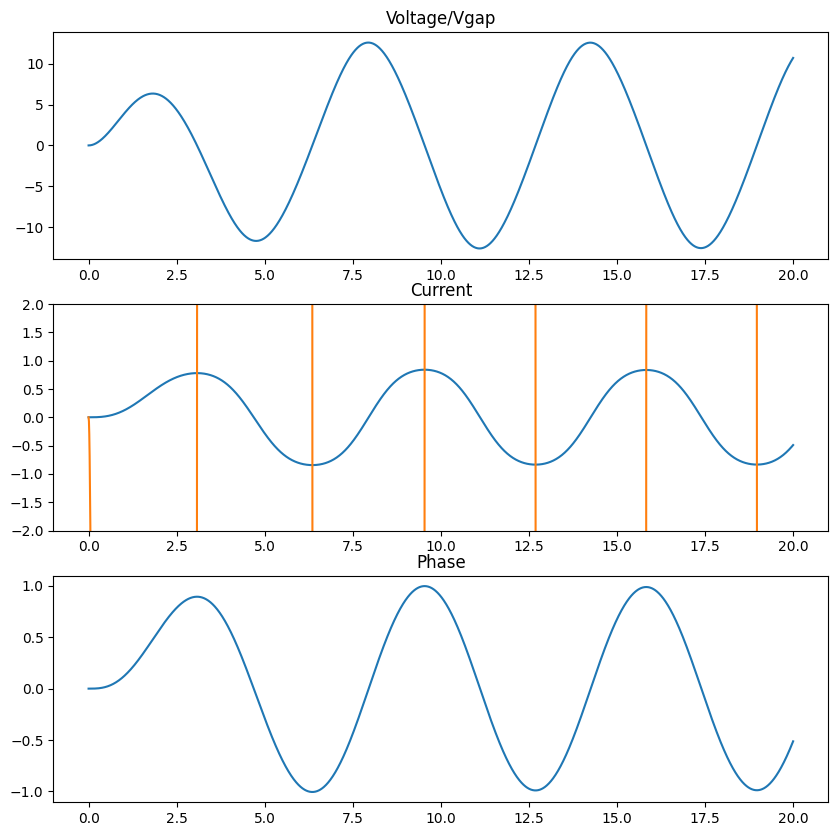

In [9]:
fig = plt.figure(figsize=(10,10))
plt.clf()
plt.subplot(3, 1, 1)
plt.title('Voltage/Vgap')
plt.plot(ts,Vjunc(ts) / Vgap)
plt.subplot(3, 1, 2)
plt.title('Current')
plt.plot(ts,np.sin(solsfunc(ts)[0]))
plt.plot(ts,(Vs(ts,params)*Ic*Rin-Vjunc(ts))/Rin/Ic)
plt.ylim([-2,2])
plt.subplot(3, 1, 3)
plt.title('Phase')
plt.plot(ts,solsfunc(ts)[0])
plt.show()
plt.close(fig)

In [8]:
import numpy as np
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# 假設這是你的 VJJmodel 函數
def VJJmodel(z, t, params):
    f, g = z
    V, Q, Vs, phi0, wp = params
    fp = g
    gp = Vs(t, params) - (1/Q(V, params) * g + np.sin(f))
    return np.array([fp, gp])

# 假設這是你的 Vs 函數
def Vs(t, params):
    # 確保返回的是標量值
    return np.sin(t)

# 假設這是你的 Q 函數
def Q(V, params):
    # 確保返回的是標量值
    return 1.0

# 假設這是你的參數和其他變數
phi0 = 1.0
wp = 1.0
params = (1.0, Q, Vs, phi0, wp)
taustop = 10  # 假設這是 taustop 的值
ts = np.linspace(0, 2 * taustop, 2000)

# 使用 odeint 進行積分
sols = odeint(VJJmodel, [0, 0], ts, args=(params,))
solsfunc = interp1d(ts, sols.T)
Vjunc = lambda x: phi0 / 2 / np.pi * wp * solsfunc(x)[1]

In [1]:
pip install stlab

ERROR: Could not find a version that satisfies the requirement stlab (from versions: none)
ERROR: No matching distribution found for stlab
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np

from scipy.signal import argrelextrema
import scipy.integrate as integrate
import scipy.special as special
from scipy.integrate import odeint
from scipy.constants import constants as const
from scipy.fftpack import fft, fftfreq

import matplotlib.pyplot as plt

from rcsj_iv import *
from funcs import ensure_dir

##################
##################

currents = np.arange(0.,1.101,0.001)
all_currents = np.concatenate([currents[:-1],currents[::-1]])
print(all_currents)

betas = [1,2,3]#np.logspace(0,2,5)#[0.2,0.5,1,4]

iv = [rcsj_iv(all_currents,beta=bb,svpng=True,printmessg=True,saveplot=True) for bb in betas]


# Plotting
[plt.plot(ivv[0],ivv[1]/bb,'.-',label=str(bb)) for ivv,bb in zip(iv,betas)]
plt.xlabel(r'$I/I_c$')
plt.ylabel(r'$V/\beta_c$')
plt.legend()
path='../plots/single_ivcs/'
ensuredir(path)
plt.savefig(path+'full_updown.png',bbox_to_inches='tight')
plt.show()
plt.close()

[0.    0.001 0.002 ... 0.002 0.001 0.   ]


TypeError: rcsj_iv() got an unexpected keyword argument 'beta'